# Assignment: API Data Visualization

**Student Name:** Peiru Liang

**Student ID:** EK6339586

**Date:** 28/11/2025

**Chosen API:** Open-mateo Historical Weather API

---

## Part 1: API Selection and Justification

**Write 1-2 paragraphs explaining:**
- Which API you chose and why
- What type of data you plan to analyze
- Why this data is interesting or relevant

I chose Open-mateo Historical Weather API for get and analyze the temperature and humidity data, to decide the starting temperature and the target temperature of the ESP32 controlled automated heating progress.

---

## Part 2: Setup and Imports

In [37]:
# Import required libraries
import requests
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from pprint import pprint

import pandas as pd

# Optional: pandas for data manipulation
# import pandas as pd

# Set matplotlib style
matplotlib.rc('xtick', labelsize=11)
matplotlib.rc('ytick', labelsize=11)
plt.style.use('ggplot')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


### API Configuration

⚠️ **Important:** Replace with your actual API credentials if required

In [38]:
# API endpoint and credentials
# Example for REE API (modify for your chosen API)

API_ENDPOINT = "https://archive-api.open-meteo.com"  # Change if using different API
# API_KEY = "YOUR_API_KEY_HERE"  # Add if your API requires authentication

# Define headers (modify based on your API)
headers = {
    'Accept': 'application/json',
    'Content-Type': 'application/json',
    'Host': 'apidatos.ree.es'
}

print("✓ API configuration set")

✓ API configuration set


---

## Part 3: Data Extraction Functions

Create reusable functions for fetching and processing data

In [39]:
def fetch_data(endpoint, params):
    """
    Fetch data from API with error handling
    
    Args:
        endpoint (str): API endpoint URL
        params (dict): Query parameters
    
    Returns:
        dict: JSON response or None if failed
    """
    try:
        # send full URL
        full_url = API_ENDPOINT + endpoint

        # send request
        response = requests.get(full_url, params=params, timeout=30)

        # check status code
        try:
            response.raise_for_status()
        except requests.HTTPError as e:
            # show server message and response text if available
            msg = f"HTTP error {response.status_code}: {e}"
            try:
                err_json = response.json()
                msg += f" | server message: {err_json}"
            except Exception:
                msg += f" | response text: {response.text[:500]}"
            raise RuntimeError(msg)

        data = response.json()

    except requests.exceptions.Timeout:
        print("✗ Request timed out")
        return None
    except requests.exceptions.ConnectionError:
        print("✗ Connection error")
        return None
    except Exception as e:
        print(f"✗ Unexpected error: {e}")
        return None

    if "hourly" not in data:
        raise RuntimeError("API did not return 'hourly' data. Full response: " + str(data))

    hourly = data["hourly"]
    df = pd.DataFrame(hourly)
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"])
        df = df.set_index("time")
    return data, df


# Test your function
# test_data = fetch_data("YOUR_ENDPOINT_HERE", params={"key": "value"})

In [40]:
def extract_timeseries(data, variable_name):
    """
    Extract time-series data from API response

    Args:
        data: API response data
        variable_name: for example, 'temperature_2m'

    Returns:
        tuple: (values, timestamps_as_datetime)
    """
    values = []
    timestamps = []

    try:
        # get from hourly
        if 'hourly' in data and variable_name in data['hourly']:
            hourly_data = data['hourly']
            values = hourly_data[variable_name]
            # turn to datetime
            timestamps = [datetime.fromisoformat(time_str.replace('Z', '+00:00'))
                         for time_str in hourly_data['time']]

        return values, timestamps
    except Exception as e:
        print(f"✗ Error extracting data: {e}")
        return [], []


print("✓ Helper functions defined")

✓ Helper functions defined


---

## Part 4: Data Collection

Fetch the data you need for your three plots

In [41]:
# Define date range for your analysis
lat, lon = 41.3851, 2.1734 # Barcelona
start_date = "2024-10-01"  # Modify as needed
end_date = "2024-12-31"    # Modify as needed
hourly_vars = "temperature_2m,precipitation"
timezone = "Europe/Madrid"
endpoint = "/v1/archive"

# Set up parameters for your API request
params = {
     "latitude": lat,
     "longitude": lon,
     "start_date": start_date,   # YYYY-MM-DD
     "end_date": end_date,       # YYYY-MM-DD
     "hourly": hourly_vars,
     "timezone": timezone
}

print(f"Fetching data from {start_date} to {end_date}...")

# done: Fetch your data
# raw_data = fetch_data(YOUR_ENDPOINT, params)

try:
    raw_json, df = fetch_data(endpoint, params)
    print("Return    :", list(raw_json.keys()))
    print("DataFrame :")
    print(df.head())
    # df.to_csv("historical_weather.csv")
    # print("SAVE AS historical_weather.csv")
except Exception as err:
    print("FETCH DATA ERROR", err)

# done: Process and extract time-series
values, times = extract_timeseries(raw_json, 'temperature_2m')
print("Data extracted:")
print(values[:10])
print(times[:10])




Fetching data from 2024-10-01 to 2024-12-31...
Return    : ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']
DataFrame :
                     temperature_2m  precipitation
time                                              
2024-10-01 00:00:00            17.3            0.0
2024-10-01 01:00:00            17.2            0.0
2024-10-01 02:00:00            17.7            0.0
2024-10-01 03:00:00            17.1            0.0
2024-10-01 04:00:00            16.7            0.0
Data extracted:
[17.3, 17.2, 17.7, 17.1, 16.7, 16.6, 16.4, 16.3, 17.1, 19.2]
[datetime.datetime(2024, 10, 1, 0, 0), datetime.datetime(2024, 10, 1, 1, 0), datetime.datetime(2024, 10, 1, 2, 0), datetime.datetime(2024, 10, 1, 3, 0), datetime.datetime(2024, 10, 1, 4, 0), datetime.datetime(2024, 10, 1, 5, 0), datetime.datetime(2024, 10, 1, 6, 0), datetime.datetime(2024, 10, 1, 7, 0), datetime.datetime(2024, 10, 1, 8, 0), datetim

In [42]:
df.describe

<bound method NDFrame.describe of                      temperature_2m  precipitation
time                                              
2024-10-01 00:00:00            17.3            0.0
2024-10-01 01:00:00            17.2            0.0
2024-10-01 02:00:00            17.7            0.0
2024-10-01 03:00:00            17.1            0.0
2024-10-01 04:00:00            16.7            0.0
...                             ...            ...
2024-12-31 19:00:00             9.0            0.0
2024-12-31 20:00:00             8.3            0.0
2024-12-31 21:00:00             7.7            0.0
2024-12-31 22:00:00             7.6            0.0
2024-12-31 23:00:00             7.6            0.0

[2208 rows x 2 columns]>

In [43]:
# Explore your data structure
# Uncomment to see the structure of your API response

# print("Data structure:")
# pprint(raw_data, depth=2)

# from df get daily temp data


---

## Part 5: Plot #1 - Basic Time-Series Line Plot (20 points)

**Requirements:**
- Single variable over time
- Minimum 24 hours of data
- Proper title, axis labels, grid, and legend
- Include average line or trend indicator
- DateTime objects on x-axis

**Description:** [Describe what this plot shows]

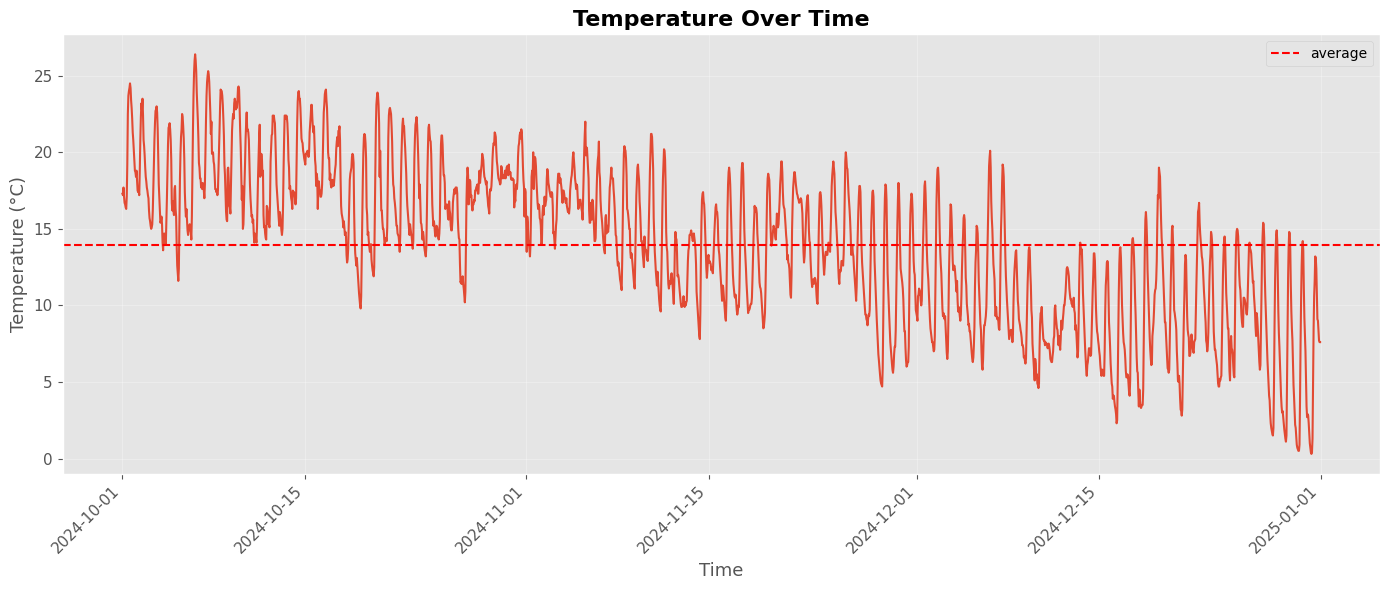

Average Temperature: 13.95°C
Min Temperature: 0.30°C
Max Temperature: 26.40°C


In [44]:
# done: Create your first plot

fig, ax = plt.subplots(figsize=(14, 6))

# Plot your data
ax.plot(times, values)

# Add average line
avg = sum(values) / len(values)
ax.axhline(y=avg, color='red', linestyle='--', label='average')

# Formatting
ax.set_title('Temperature Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Time', fontsize=13)
ax.set_ylabel('Temperature (°C)', fontsize=13)
ax.legend()

ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Average Temperature: {avg:.2f}°C")
print(f"Min Temperature: {min(values):.2f}°C")
print(f"Max Temperature: {max(values):.2f}°C")

### Analysis for Plot #1

**Key Observations:**
- [What patterns do you see?]
- [Any interesting trends?]
- [What might explain the patterns?]

Precipitation is mainly concentrated from the last week of October to the third week of November.

Precipitation can significantly lead to a decrease in temperature and a reduction in the temperature difference between high and low on the same day.

The explanation is that precipitation leads to insufficient sunlight, which usually occurs at noon. The warming phenomenon caused by sunlight is prevented by precipitation.

---

## Part 6: Plot #2 - Comparative Time-Series (20 points)

**Requirements:**
- Compare at least 2 different time-series
- Clear differentiation (colors, line styles, markers)
- Legend explaining each series
- Brief interpretation of the comparison

**Description:** [Describe what this plot compares]

In [45]:
# done: Fetch/prepare second dataset if needed
# data2 = fetch_data(...)
# values2, times2 = extract_timeseries(...)
values1, times = extract_timeseries(raw_json, 'precipitation')
print(values1[:10])
print(times[:10])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[datetime.datetime(2024, 10, 1, 0, 0), datetime.datetime(2024, 10, 1, 1, 0), datetime.datetime(2024, 10, 1, 2, 0), datetime.datetime(2024, 10, 1, 3, 0), datetime.datetime(2024, 10, 1, 4, 0), datetime.datetime(2024, 10, 1, 5, 0), datetime.datetime(2024, 10, 1, 6, 0), datetime.datetime(2024, 10, 1, 7, 0), datetime.datetime(2024, 10, 1, 8, 0), datetime.datetime(2024, 10, 1, 9, 0)]


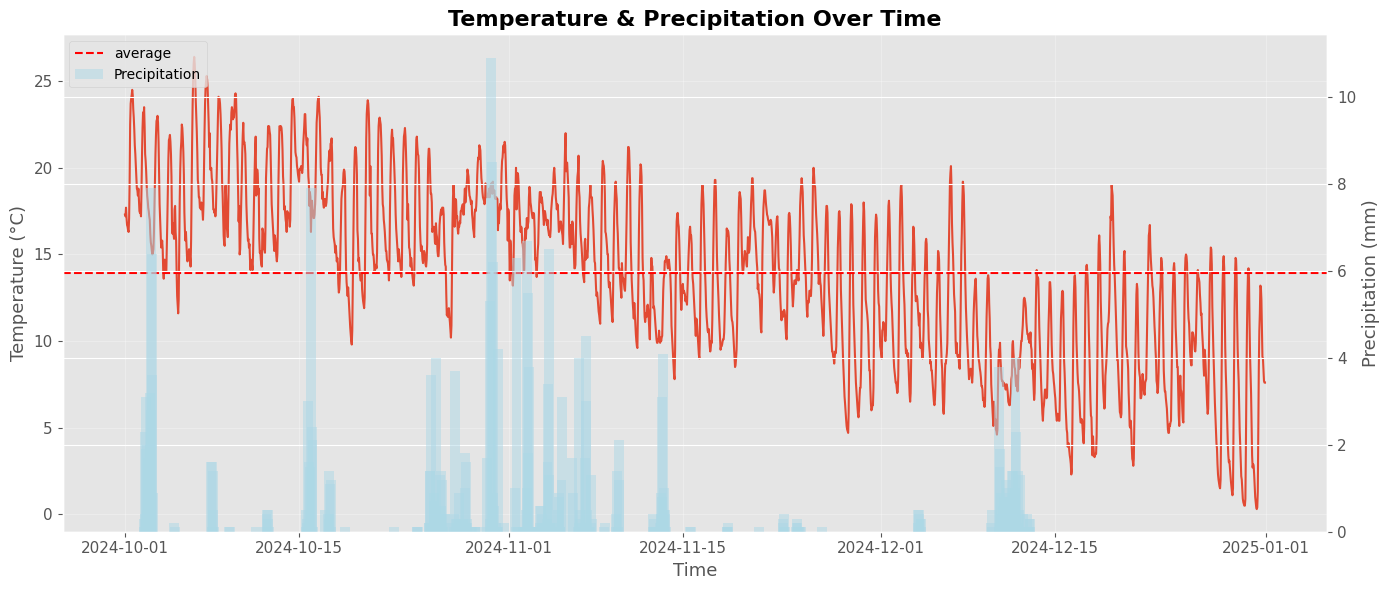

Average Temperature: 13.95°C
Min Temperature: 0.30°C
Max Temperature: 26.40°C
Total Precipitation Points: 314


In [46]:
# done: Create your comparison plot

fig, ax = plt.subplots(figsize=(14, 6))

# Plot your data
ax.plot(times, values)

# Add average line
avg = sum(values) / len(values)
ax.axhline(y=avg, color='red', linestyle='--', label='average')

# Add humidity
ax2 = ax.twinx()
ax2.bar(times, values1, alpha=0.5, color='lightblue', label='Precipitation')

# Formatting
ax.set_title('Temperature & Precipitation Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Time', fontsize=13)
ax.set_ylabel('Temperature (°C)', fontsize=13)
ax2.set_ylabel('Precipitation (mm)', fontsize=13)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Average Temperature: {avg:.2f}°C")
print(f"Min Temperature: {min(values):.2f}°C")
print(f"Max Temperature: {max(values):.2f}°C")
print(f"Total Precipitation Points: {len([p for p in values1 if p > 0])}")

In [47]:
# correlated matrix of values and values1
corr = np.corrcoef(values, values1)
print(corr)

[[1.         0.07434973]
 [0.07434973 1.        ]]


### Analysis for Plot #2

**Comparison Insights:**
- [How do the two series relate?]
- [Are they correlated or inversely related?]
- [What causes the differences?]

Precipitation is mainly concentrated from the last week of October to the third week of November. It can possibly lead to a decrease in temperature and a reduction in the temperature difference between high and low on the same day.

The temperature itself is weakly positive (0.07) correlated with precipitation. Still  need further research to see the link between them.

The explanation is that precipitation leads to insufficient sunlight, which usually occurs at noon. The warming phenomenon caused by sunlight is prevented by precipitation.

---

## Part 7: Plot #3 - Advanced Visualization (20 points)

**Requirements:**
- Aggregated or processed time-series data
- Advanced visualization type (stacked area, heatmap, box plot, dual-axis)
- Professional formatting
- Statistical analysis or key findings displayed

**Description:** [Describe your advanced visualization approach]

In [55]:
# done: Prepare data for advanced visualization
# This might involve aggregation, grouping, or calculating derived metrics

# Example for stacked area:
# data_by_category = {...}  # Dictionary of categories and their values over time

# Example for heatmap:
# hourly_patterns = aggregate_by_hour_and_day(data)

# Example for box plot:


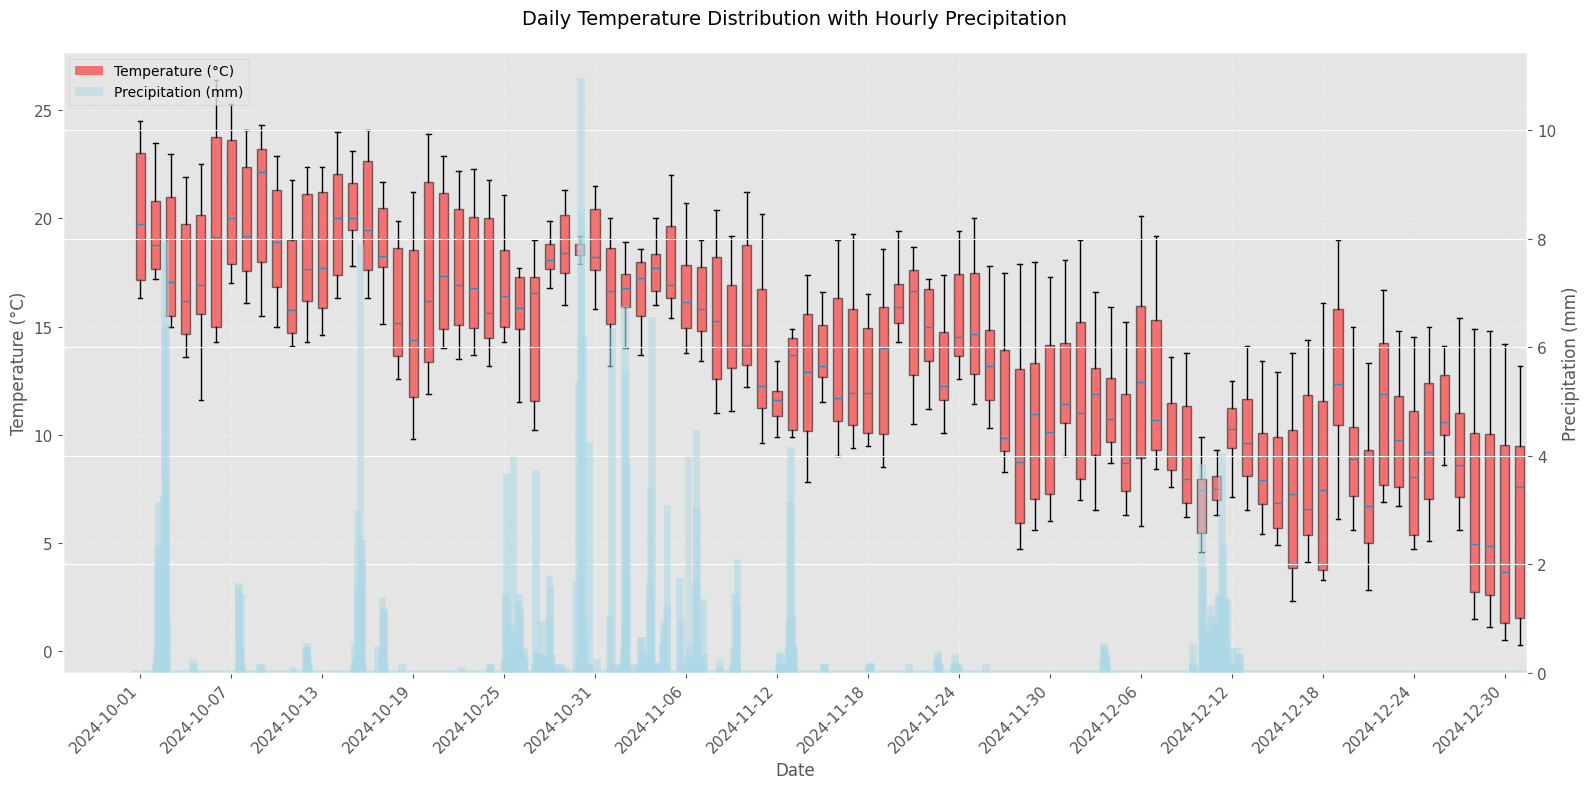

In [63]:
if not pd.api.types.is_datetime64_any_dtype(df.index):
    df.index = pd.to_datetime(df.index)

df['date'] = df.index.date
df['hour'] = df.index.hour

fig, ax1 = plt.subplots(figsize=(16, 8))

temperature_data = []
dates = []
for date, group in df.groupby('date'):
    dates.append(date)
    temperature_data.append(group['temperature_2m'].values)

box = ax1.boxplot(temperature_data, positions=range(len(dates)),
                  widths=0.6, patch_artist=True, showfliers=False)

for patch in box['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.5)

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()

precip_df = pd.DataFrame({
    'date': df['date'],
    'hour': df['hour'],
    'precipitation': df['precipitation'],
    'date_index': df['date'].apply(lambda x: dates.index(x))
})

precip_df['x_position'] = precip_df['date_index'] + precip_df['hour']/24 - 0.5

bars = ax2.bar(precip_df['x_position'], precip_df['precipitation'],
               width=1/24, alpha=0.5, color='lightblue', edgecolor='lightblue', linewidth=5)

ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.tick_params(axis='y')

n = len(dates)
if n > 30:
    step = max(1, n // 15)
    tick_positions = list(range(0, n, step))
    tick_labels = [str(dates[i]) for i in tick_positions]
else:
    tick_positions = range(n)
    tick_labels = [str(d) for d in dates]

ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.title('Daily Temperature Distribution with Hourly Precipitation', fontsize=14, pad=20)

ax1.grid(True, alpha=0.3, linestyle='--')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.5, label='Temperature (°C)'),
    Patch(facecolor='lightblue', alpha=0.5, label='Precipitation (mm)')
]
ax1.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [89]:
# Advanced statistical analysis
# TODO: Calculate relevant statistics for your visualization

# Examples:
# - Correlation coefficients
# - Percentage breakdown
# - Peak hour analysis
# - Variability measures

print("📊 Statistical Summary:")
# print(f"  Metric 1: {value}")
# print(f"  Metric 2: {value}")

📊 Statistical Summary:


### Analysis for Plot #3

**Advanced Insights:**
- [What patterns emerge from the aggregated view?]
- [What are the key statistical findings?]
- [What's the main story this visualization tells?]

[Your analysis here]

---

## Part 8: Overall Conclusions

**Summary of Findings:**

[Write a summary paragraph bringing together insights from all three plots]

**Challenges Encountered:**

[Describe any difficulties you faced and how you solved them]

**Potential Extensions:**

[What additional analysis could be interesting with this data?]

---

## Part 9: Code Quality Check

Before submitting, verify:

- [ ] All code cells run without errors
- [ ] All plots are properly labeled and formatted
- [ ] Functions include docstrings
- [ ] Error handling is implemented
- [ ] Comments explain complex logic
- [ ] README.md file is complete
- [ ] No hardcoded API keys (or marked clearly for replacement)
- [ ] All three plots meet the requirements

---

## Appendix: Helper Functions (Optional)

Add any additional helper functions you created:

In [90]:
# Additional helper functions

def your_helper_function():
    """
    Description of what this function does
    """
    pass